## The Unreasonable Effectiveness of Linear Regression

- Ok, so we've gone through the basics of how hypothesis testing works, and also the building blocks of do-calculus

- Let's start by discussing the simplest, best known, and most theoretically accessible approach to causal inference; the OLS regression

- I won't talk too much about the theory of OLS here, because I've already covered it elsewhere (See the datascience repo for algorithm implementations). The focus here will be looking into why OLS works as a causal inference method

- Let's reuse the set up from previous chapters
    - We have a set of $N$ individuals
    - We have a treatment $T$ we wish to test on these individuals, which can be 0 (untreated) or 1 (treated)
    - We define the effect of treatment $T$ as $\tau$. That is, for person $i$, the treatment effect of $T$ is $\tau_i$
    - We have some outcome $Y$ that we wish to measure for each individual
    - So for every individual $i$, we want to measure $\tau_i$, which is defined as difference in outcomes of the individual under treatment $Y_{1,i}$ and the outcome of the individual with no treatment $Y_{0,i}$

### Background Recap

- As we discussed previously, there is no way to both give a treatment and not give a treatment to the same individual. That is, for any individual $i$, we observe $Y_{0,i}$ if $T_i = 0$ and $Y_{1,i}$ if $T_i = 1$
$$\begin{aligned}
    Y_i &= Y_{0,i} + T_i (Y_{1, i} - Y_{0, i})
\end{aligned}$$

- So instead, we substitute this by estimating the average treatment effect (ATE), where we measure if the treatment works **on average** beteween the treated and untreated
$$\begin{aligned}
    ATE &= E[Y_1 - Y_0] \\
    &= E[Y | T=1] - E[Y | T=0]
\end{aligned}$$

- But from chapter `1. Intro to Causality`, we know that $E[Y | T = 1] - E[Y | T = 0]$ is not always a good indicator of ATE. Because often, the populations of $T=1$ and $T=0$ are quite different from eac other! Let's see how bias arises
$$\begin{aligned}
    E[Y|T=1] - E[Y|T=0] &= E[Y_1|T=1] - E[Y_0|T=0] & \text{Population diff in expectation between T=1/T=0 outcomes} \\
    &= E[Y_1|T=1] - E[Y_0|T=0] + E[Y_0|T=1] - E[Y_0|T=1] & \text{Adding and subtracting the same term} \\
    &= (E[Y_1|T=1] - E[Y_0|T=1]) + (E[Y_0|T=1] - E[Y_0|T=0]) \\
    &= \underbrace{E[Y_1 - Y_0 | T=1]}_{\text{Avg Treatment Effect on Treated}} + \underbrace{1(E[Y_0|T=1] - E[Y_0|T=0])}_{\text{Bias}} \\
\end{aligned}$$

- Therefore, $ATE = E[Y|T=1] - E[Y|T=0]$ if and only if $E[Y_0|T=1] - E[Y_0|T=0] = 0$. 
    - That is, there must be no difference in the untreated baseline outcome in the treatment and control groups

- To enforce this condition that $E[Y_0|T=1] - E[Y_0|T=0] = 0$, we previously discussed RCTs. 
    - Since well controlled RCTs enforce that there is no variation in the treatment and control groups BESIDES the treatment intervention, this conditgion is met by definition

### Linear Regression

- Linear regression helps us take our hypothesis testing one step forward.In previous hypothesis testing examples, we have only ever done hypothesis tests on single variables assuming all else is equal. This is useful, but often insufficient. 

- This is because hypothesis testing is only operating on changing 1 variable. But in the real world, we often have multiple things changing at once, which violates the core assumption of the hypothesis test. 
    - For example, if we want to measure the effect of education on wages
    - But wages are also affected by IQ, and education is also affected by IQ
    - In such a case, we may want to do a hypothesis test of th effect of education on wages, conditioning on IQ. 
    - OLS simply lets us do this conditioning automatically

- To illustrate the power of OLS, let's reuse our example of trying to understand the effect of online classes on exam results. For simplicity, we only look at online classes vs fully in-person classes, disregarding the blended case for now. 

In [14]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

data = pd.read_csv('./data/2_online_classroom.csv').query("format_blended==0")
result = smf.ols('falsexam ~ format_ol', data=data).fit()

display(result.summary().tables[1])
print(f"{result.params['Intercept'] + result.params['format_ol']=}")

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,78.5475,1.113,70.563,0.000,76.353,80.742
format_ol,-4.9122,1.680,-2.925,0.004,-8.223,-1.601


result.params['Intercept'] + result.params['format_ol']=np.float64(73.63526308510642)


In [4]:
data.groupby('format_ol')['falsexam'].mean()

format_ol
0    78.547485
1    73.635263
Name: falsexam, dtype: float64

In [12]:
result.params['Intercept'] + result.params['format_ol']

np.float64(73.63526308510642)

- Notice this amazing result! The OLS regression gives the same average effect of treatment (78.5) and no treatment (73.64) compared to taking average values

### Why can we just "add" variables to OLS and claim that the $\beta$ is the partial effect?

- See `data_science/Machine Learning Algorithms Implementation/Regression/OLS/8. Multivariate OLS.ipynb`


### Applying OLS: Non-Random Data

- So far we've seen how hypothesis testing works with random data. that is, data that comes to you nice and randomised between treatment and control

- IRL though, you're infinitely more likely to come across non random data (i.e. observational data). We'll now look at how we can use OLS to analyse observational data, without running an explicit experiment

- We will look at the effect of an additional year of education on wages. We assume that an additional unit of education will affect wages geometrically, so we express the dependent variable in log terms. That is, we take $\log \text{Wages} = \beta_1 \text{Years of Education} + \epsilon$

- In this functional form $\log y = \beta x$, a unit change in X is **approximately** to a $\beta*100$% change in $y$. If you are wondering why, see `data_science/Machine Learning Algorithms Implementation/Regression/OLS/9. Log Specification in OLS.ipynb`

In [11]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

wage = pd.read_csv("./data/4_wage.csv").dropna()
model_1 = smf.ols('np.log(hwage) ~ educ', data=wage.assign(hwage=wage["wage"]/wage["hours"])).fit()
model_1.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.3071,0.104,22.089,0.000,2.102,2.512
educ,0.0536,0.008,7.114,0.000,0.039,0.068


- From the regression coefficients, we find that an extra year of education increases hourly wage by approximately 5.36%

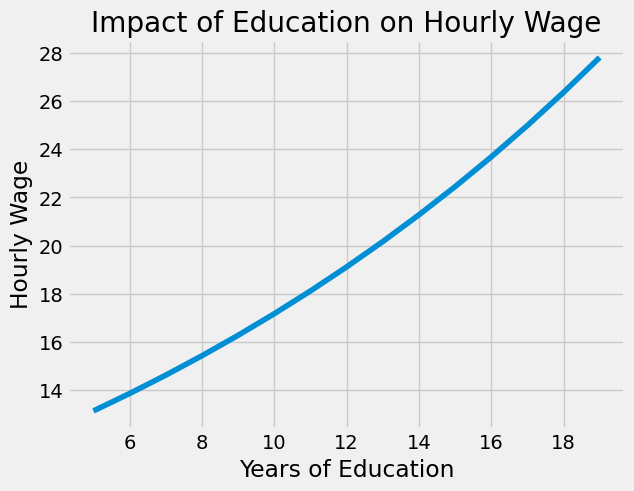

In [13]:
from matplotlib import pyplot as plt
from matplotlib import style
style.use("fivethirtyeight")

x = np.array(range(5, 20))
plt.plot(x, np.exp(model_1.params["Intercept"] + model_1.params["educ"] * x))
plt.xlabel("Years of Education")
plt.ylabel("Hourly Wage")
plt.title("Impact of Education on Hourly Wage")
plt.show()

- But this is obviously not sufficient to claim that "education causes higher wages". 
    - For one thing, smarter people get more education, and smarter people get more wages too

- You can tell many other similar stories, but the key point is this: those who get more education are more likely to have higher hourly wages anyway, **regardless** of the years of education
    - Or to bring it back to the math we're already familiar with, $E[\text{Wage} | \text{Education=low}] < E[\text{Wage} | \text{Education=high}]$ 

- This violates our earlier assertion, that $E[Y_0|T=1] - E[Y_0|T=0] = 0$, which means that we has **bias** in our estimate

#### Controlling for other variables

- 